In [ ]:
"""
run_p1_p2.py  –  Log-of-quadratic: dual decomposition comparison

Problem:  F(x) = log(Q(x)) + 8,   Q(x) = ||A(x - x̄)||² + c
  with A = diag(√5, 1),  x̄ = (5,2),  c = e^{-8}.

Two decompositions of the SAME function:
  p1 → h(C(x)):  h = -log(·)+8,  C(x) = 1/Q(x)  → prox-linear (linearize C)
  p2 → s(R(x)):  s = log(·)+8,   R(x) = Q(x)     → prox-convex (linearize s, keep R exact)

This script runs:
  A) Adaptive regime: all three methods with same trust-region params
  B) Reports non-adaptive iteration counts (from previously computed values)

IMPORTANT: Requires pc_solve.py, pc_parse.py in the same directory.
"""

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import cvxpy as cp
import jax.numpy as jnp
from jax import jacfwd, jit, config
config.update("jax_enable_x64", True)

from pc_solve import prox_convex

# ── Style ──────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'text.usetex': False,
})

C_PG  = '#d62728'   # red    – prox-gradient
C_PL  = '#ff7f0e'   # orange – prox-linear
C_PCX = '#1f77b4'   # blue   – prox-convex

FIGDIR = 'figures/p1_p2'
os.makedirs(FIGDIR, exist_ok=True)

def safe_log(arr, eps=1e-20):
    return np.log(np.maximum(np.asarray(arr, dtype=float), eps))

In [2]:
def p1_problem_parameters():

    prb_params = dict()

    # ------------------------------------------------------------

    A = np.array([[np.sqrt(5.0), 0.0],
                 [0.0, 1.0]])
    c = np.exp(-8.0)
    x_shft = np.array([5.0, 2.0])

    R_dim, x_dim, C_dim = 1, 2, 1

    x_val = np.array([1.5, -1.5], dtype=float)
    y_val = np.zeros(R_dim)

    # ------------------------------------------------------------

    prb_params['R_dim'] = R_dim
    prb_params['x_dim'] = x_dim
    prb_params['C_dim'] = C_dim

    prb_params['x_val'] = x_val

    prb_params['adaptive_step'] = False
    prb_params['r_inc'] = 1.2
    prb_params['r_decr'] = 1.2
    prb_params['r0'] = 0.01
    prb_params['r1'] = 0.1
    prb_params['r2'] = 0.8

    prb_params['w_ptr_val'] = 1e-2
    prb_params['term_val'] = 1e-7
    prb_params['ITE'] = 100000

    prb_params['solver_list'] = ['OSQP', 'QOCO', 'MOSEK', 'CLARABEL', 'ECOS'][3]
    prb_params['use_generated_code'] = False

    # ------------------------------------------------------------

    # ------------------------------------------
    # Convex
    # ------------------------------------------

    def convex_cp(x):
        return 0.0

    def convex_cp_np(x):
        return 0.0

    # ------------------------------------------

    def h_cp(y2_val):
        return cp.sum(-cp.log(y2_val)) + 8.0

    def h_jax(y2_val):
        return -jnp.sum(jnp.log(y2_val)) + 8.0

    def C(x_val):
        t = jnp.sum(jnp.square(A @ (x_val-x_shft))) + c  # assume t > 0
        return jnp.array([1.0 / t])

    def hC(x_val):
        return h_jax(C(x_val))

    # ------------------------------------------

    def R_cp(x_val):
        return cp.hstack([0.0])

    def R_jax(x_val):
        return jnp.array([jnp.sum(jnp.square(A @ (x_val-x_shft))) + c]) * 0.0

    def s(y_val):
        return 0.0

    def sR(x_val):
        return s(R_jax(x_val))

    # ------------------------------------------

    def comp(x_val):
        return convex_cp_np(x_val) + hC(x_val) + sR(x_val)

    # ------------------------------------------

    prb_params['hC'] = jit(hC).lower(x_val).compile()
    prb_params['g_hC'] = jit(jacfwd(hC)).lower(x_val).compile()

    prb_params['C'] = jit(C).lower(x_val).compile()
    prb_params['g_C'] = jit(jacfwd(C)).lower(x_val).compile()

    prb_params['sR'] = jit(sR).lower(x_val).compile()
    prb_params['g_sR'] = jit(jacfwd(sR)).lower(x_val).compile()

    prb_params['g_s'] = jit(jacfwd(s)).lower(y_val).compile()
    prb_params['R_jax'] = jit(R_jax).lower(x_val).compile()

    prb_params['comp'] = jit(comp).lower(x_val).compile()

    prb_params['convex_cp'] = convex_cp
    prb_params['h_cp'] = h_cp
    prb_params['R_cp'] = R_cp

    return prb_params


In [3]:
def p2_problem_parameters():

    prb_params = dict()

    # ------------------------------------------------------------

    A = np.array([[np.sqrt(5.0), 0.0],
                [0.0, 1.0]])
    c = np.exp(-8.0)
    x_shft = np.array([5.0, 2.0])

    R_dim, x_dim, C_dim = 1, 2, 1

    x_val = np.array([1.5, -1.5], dtype=float)
    y_val = np.zeros(R_dim)

    # ------------------------------------------------------------

    prb_params['R_dim'] = R_dim
    prb_params['x_dim'] = x_dim
    prb_params['C_dim'] = C_dim

    prb_params['x_val'] = x_val

    prb_params['adaptive_step'] = False
    prb_params['r_inc'] = 1.2
    prb_params['r_decr'] = 1.2
    prb_params['r0'] = 0.01
    prb_params['r1'] = 0.1
    prb_params['r2'] = 0.8

    prb_params['w_ptr_val'] = 1e-2
    prb_params['term_val'] = 1e-7
    prb_params['ITE'] = 100000

    prb_params['solver_list'] = ['OSQP', 'QOCO', 'MOSEK', 'CLARABEL', 'ECOS'][3]
    prb_params['use_generated_code'] = False

    # ------------------------------------------------------------

    # ------------------------------------------
    # Convex
    # ------------------------------------------

    def convex_cp(x):
        return 0.0

    def convex_cp_np(x):
        return 0.0

    # ------------------------------------------

    def h_cp(y2_val):
        return cp.sum(-cp.log(y2_val))*0.0

    def h_jax(y2_val):
        return -jnp.sum(jnp.log(y2_val))*0.0

    def C(x_val):
        t = jnp.sum(jnp.square(A @ (x_val-x_shft))) + c  # assume t > 0
        return jnp.array([1.0 / t])

    def hC(x_val):
        return h_jax(C(x_val))

    # ------------------------------------------

    def R_cp(x_val):
        return cp.hstack([cp.sum(cp.square(A @ (x_val-x_shft))) + c])

    def R_jax(x_val):
        return jnp.array([jnp.sum(jnp.square(A @ (x_val-x_shft))) + c])

    def s(y_val):
        return jnp.sum(jnp.log(y_val)) + 8.0

    def sR(x_val):
        return s(R_jax(x_val))

    # ------------------------------------------

    def comp(x_val):
        return convex_cp_np(x_val) + hC(x_val) + sR(x_val)

    # ------------------------------------------

    prb_params['hC'] = jit(hC).lower(x_val).compile()
    prb_params['g_hC'] = jit(jacfwd(hC)).lower(x_val).compile()

    prb_params['C'] = jit(C).lower(x_val).compile()
    prb_params['g_C'] = jit(jacfwd(C)).lower(x_val).compile()

    prb_params['sR'] = jit(sR).lower(x_val).compile()
    prb_params['g_sR'] = jit(jacfwd(sR)).lower(x_val).compile()

    prb_params['g_s'] = jit(jacfwd(s)).lower(y_val).compile()
    prb_params['R_jax'] = jit(R_jax).lower(x_val).compile()

    prb_params['comp'] = jit(comp).lower(x_val).compile()

    prb_params['convex_cp'] = convex_cp
    prb_params['h_cp'] = h_cp
    prb_params['R_cp'] = R_cp

    return prb_params


In [4]:
# ═══════════════════════════════════════════════════════════════
# Load problem definitions
# ═══════════════════════════════════════════════════════════════

p1_params = p1_problem_parameters()
p2_params = p2_problem_parameters()

In [5]:
# ═══════════════════════════════════════════════════════════════
# A) Adaptive regime
# ═══════════════════════════════════════════════════════════════

print('=' * 70)
print('ADAPTIVE REGIME: all three methods, same trust-region params')
print('=' * 70)

# Common adaptive parameters
adaptive_cfg = {
    'adaptive_step': True,
    'r_inc': 1.2,
    'r_decr': 1.2,
    'r0': 0.1,
    'r1': 0.25,
    'r2': 0.75,
    'w_ptr_val': 1e-1,
    'term_val': 1e-7,
    'term_dx': 1e-10,
    'ITE': 100000,
}

# ── prox-gradient (p1: full linearization) ────────────────────
print('\n--- prox-gradient ---')
for k, v in adaptive_cfg.items():
    p1_params[k] = v
# p1_params['adaptive_step'] = False
# p1_params['w_ptr_val'] = 2260
res_pg = prox_convex(alg_type='prox_gradient', prb_params=p1_params)

# ── prox-linear (p1: h = -log, C = 1/Q) ──────────────────────
print('\n--- prox-linear ---')
for k, v in adaptive_cfg.items():
    p1_params[k] = v
# p1_params['adaptive_step'] = False
# p1_params['w_ptr_val'] = 2110
res_pl = prox_convex(alg_type='prox_linear', prb_params=p1_params)

# ── prox-convex (p2: s = log, R = Q) ─────────────────────────
print('\n--- prox-convex ---')
for k, v in adaptive_cfg.items():
    p2_params[k] = v
p2_params['w_ptr_val'] = 1e-8
res_pcx = prox_convex(alg_type='prox_convex', prb_params=p2_params)

ADAPTIVE REGIME: all three methods, same trust-region params

--- prox-gradient ---
Problem parameters:  dict_keys(['sR', 'grad_sR', 'hC', 'grad_hC', 'w_ptr', 'xk'])
DPP:  True
Iter 0, J_xk: 12.2973, J_diff: 1.562583e+00, L_diff: 5.895638e-01, Ratio: 2.6504, dx: 2.428093e+00, w_ptr: 0.1000, dt: 0.0168
Iter 1, J_xk: 10.7347, J_diff: -1.234010e+00, L_diff: 2.045367e+00, Ratio: -0.6033, dx: 4.954230e+00, w_ptr: 0.0833, dt: 0.0020
-----------------------------------Reject-----------------------------------
Iter 1, J_xk: 10.7347, J_diff: -7.527347e-01, L_diff: 1.704472e+00, Ratio: -0.4416, dx: 4.128525e+00, w_ptr: 0.1000, dt: 0.0022
-----------------------------------Reject-----------------------------------
Iter 1, J_xk: 10.7347, J_diff: -2.671649e-01, L_diff: 1.420393e+00, Ratio: -0.1881, dx: 3.440438e+00, w_ptr: 0.1200, dt: 0.0010
-----------------------------------Reject-----------------------------------
Iter 1, J_xk: 10.7347, J_diff: 2.007414e-01, L_diff: 1.183661e+00, Ratio: 0.1696, 

In [6]:
# ═══════════════════════════════════════════════════════════════
# Summary
# ═══════════════════════════════════════════════════════════════

print('\n' + '=' * 70)
print('RESULTS SUMMARY')
print('=' * 70)

def summarize(name, res):
    n_acc = len(res['x_val_list']) - 1
    n_tot = len(res['times'])
    Ff = float(np.asarray(res['J_list'][-1]))
    dt = res['scp_solve_time']
    dt_avg = np.mean(res['times']) if res['times'] else 0.0
    xf = res['x_val_list'][-1]
    print(f"  {name:16s}  acc={n_acc:5d}  solves={n_tot:5d}  "
          f"F*={Ff:10.4e}  time={dt:.4f}s  avg/solve={dt_avg:.6f}s  "
          f"x*=[{xf[0]:.4f}, {xf[1]:.4f}]")

summarize('prox-gradient', res_pg)
summarize('prox-linear',   res_pl)
summarize('prox-convex',   res_pcx)

print('\nNon-adaptive reference (from prior runs):')
print('  prox-gradient:  w=2260, ~27697 iters to |ΔF|<1e-7')
print('  prox-linear:    w=2110, ~25873 iters to |ΔF|<1e-7')
print('  prox-convex:    w→0,    1 iter  (global majorizer)')


RESULTS SUMMARY
  prox-gradient     acc=   37  solves=   96  F*=1.6852e-08  time=0.0855s  avg/solve=0.000751s  x*=[5.0000, 2.0000]
  prox-linear       acc=   54  solves=   93  F*=1.1427e-08  time=0.0740s  avg/solve=0.000647s  x*=[5.0000, 2.0000]
  prox-convex       acc=    2  solves=    2  F*=0.0000e+00  time=0.0063s  avg/solve=0.002702s  x*=[5.0000, 2.0000]

Non-adaptive reference (from prior runs):
  prox-gradient:  w=2260, ~27697 iters to |ΔF|<1e-7
  prox-linear:    w=2110, ~25873 iters to |ΔF|<1e-7
  prox-convex:    w→0,    1 iter  (global majorizer)



Saved figures/p1_p2/logquad_convergence.pdf


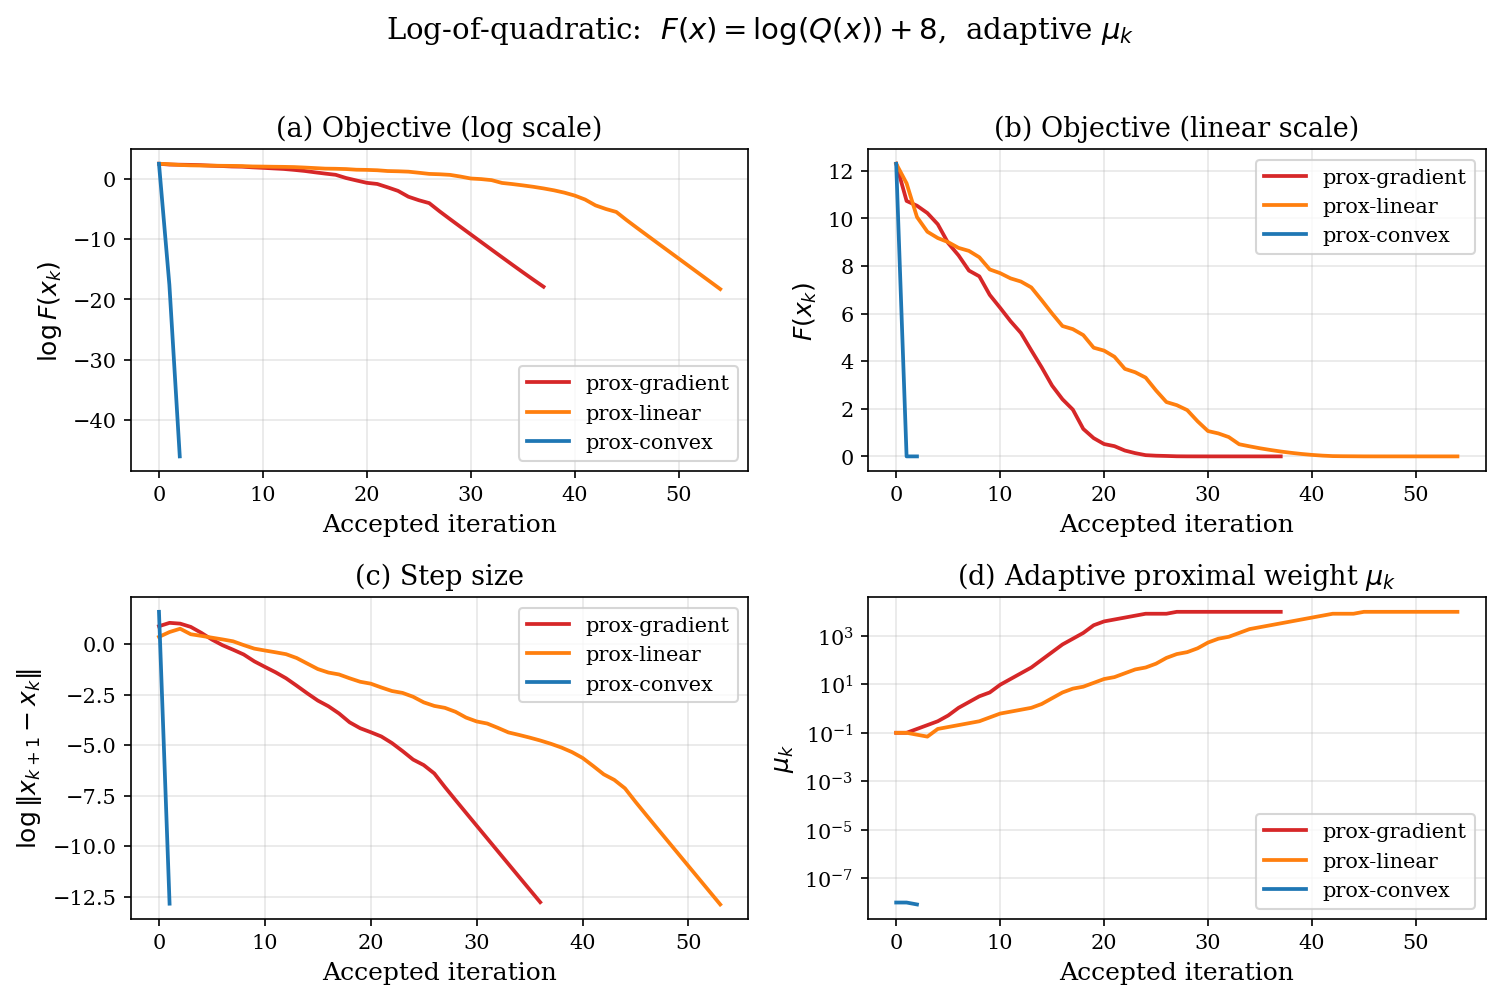

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Paper Figure: Adaptive convergence (2x2)
# ═══════════════════════════════════════════════════════════════

fig, axs = plt.subplots(2, 2, figsize=(10, 6.5))

J_pg  = np.asarray(res_pg['J_list'], dtype=float)
J_pl  = np.asarray(res_pl['J_list'], dtype=float)
J_pcx = np.asarray(res_pcx['J_list'], dtype=float)

# (a) log F
axs[0, 0].plot(safe_log(J_pg),  c=C_PG,  label='prox-gradient')
axs[0, 0].plot(safe_log(J_pl),  c=C_PL,  label='prox-linear')
axs[0, 0].plot(safe_log(J_pcx), c=C_PCX, label='prox-convex')
axs[0, 0].set_ylabel(r'$\log F(x_k)$')
axs[0, 0].set_xlabel('Accepted iteration')
axs[0, 0].legend()
axs[0, 0].set_title('(a) Objective (log scale)')
axs[0, 0].grid(True, alpha=0.3)

# (b) F linear
axs[0, 1].plot(J_pg,  c=C_PG,  label='prox-gradient')
axs[0, 1].plot(J_pl,  c=C_PL,  label='prox-linear')
axs[0, 1].plot(J_pcx, c=C_PCX, label='prox-convex')
axs[0, 1].set_ylabel(r'$F(x_k)$')
axs[0, 1].set_xlabel('Accepted iteration')
axs[0, 1].legend()
axs[0, 1].set_title('(b) Objective (linear scale)')
axs[0, 1].grid(True, alpha=0.3)

# (c) log ||dx||
dx_pg  = np.asarray(res_pg['dx_list'], dtype=float)
dx_pl  = np.asarray(res_pl['dx_list'], dtype=float)
dx_pcx = np.asarray(res_pcx['dx_list'], dtype=float)
axs[1, 0].plot(safe_log(dx_pg),  c=C_PG,  label='prox-gradient')
axs[1, 0].plot(safe_log(dx_pl),  c=C_PL,  label='prox-linear')
axs[1, 0].plot(safe_log(dx_pcx), c=C_PCX, label='prox-convex')
axs[1, 0].set_ylabel(r'$\log \|x_{k+1} - x_k\|$')
axs[1, 0].set_xlabel('Accepted iteration')
axs[1, 0].legend()
axs[1, 0].set_title(r'(c) Step size')
axs[1, 0].grid(True, alpha=0.3)

# (d) mu_k
w_pg  = np.asarray(res_pg['w_ptr_val_list'], dtype=float)
w_pl  = np.asarray(res_pl['w_ptr_val_list'], dtype=float)
w_pcx = np.asarray(res_pcx['w_ptr_val_list'], dtype=float)
axs[1, 1].semilogy(w_pg,  c=C_PG,  label='prox-gradient')
axs[1, 1].semilogy(w_pl,  c=C_PL,  label='prox-linear')
axs[1, 1].semilogy(w_pcx, c=C_PCX, label='prox-convex')
axs[1, 1].set_ylabel(r'$\mu_k$')
axs[1, 1].set_xlabel('Accepted iteration')
axs[1, 1].legend()
axs[1, 1].set_title(r'(d) Adaptive proximal weight $\mu_k$')
axs[1, 1].grid(True, alpha=0.3)

fig.suptitle(r'Log-of-quadratic:  $F(x) = \log(Q(x)) + 8$,  adaptive $\mu_k$',
             fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/logquad_convergence.pdf')
fig.savefig(f'{FIGDIR}/logquad_convergence.png')
print(f'\nSaved {FIGDIR}/logquad_convergence')
plt.show()

Saved figures/p1_p2/logquad_trajectory.pdf


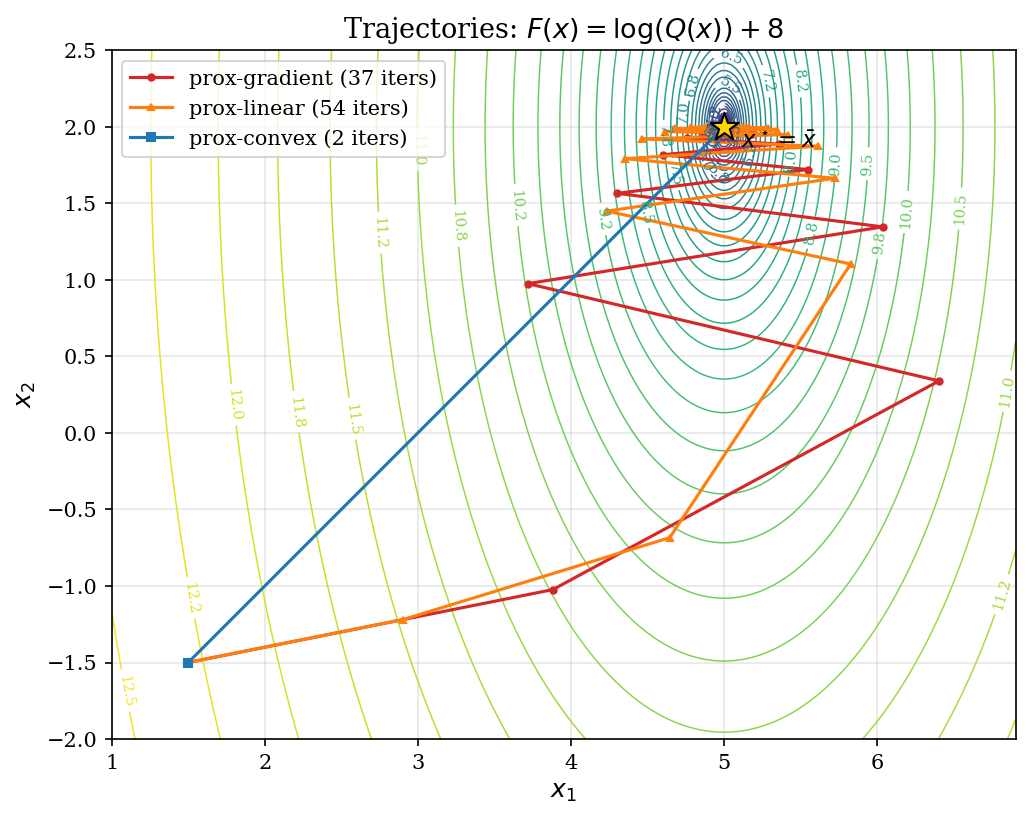

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Trajectory over level sets
# ═══════════════════════════════════════════════════════════════

xv_pg  = np.asarray(res_pg['x_val_list'], dtype=float)
xv_pl  = np.asarray(res_pl['x_val_list'], dtype=float)
xv_pcx = np.asarray(res_pcx['x_val_list'], dtype=float)

# Bounds
pad = 0.5
all_x = np.vstack([xv_pg, xv_pl, xv_pcx])
x1_min = all_x[:, 0].min() - pad
x1_max = all_x[:, 0].max() + pad
x2_min = all_x[:, 1].min() - pad
x2_max = all_x[:, 1].max() + pad

x1g = np.linspace(x1_min, x1_max, 201)
x2g = np.linspace(x2_min, x2_max, 201)
X1, X2 = np.meshgrid(x1g, x2g)
Z = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        Z[i, j] = float(np.asarray(p1_params['comp'](
            np.array([X1[i, j], X2[i, j]]))))

fig2, ax = plt.subplots(figsize=(7, 6))
CS = ax.contour(X1, X2, Z, levels=50, cmap='viridis', linewidths=0.7)
ax.clabel(CS, inline=True, fontsize=7, fmt='%.1f')

n_pg  = len(xv_pg) - 1
n_pl  = len(xv_pl) - 1
n_pcx = len(xv_pcx) - 1

ax.plot(xv_pg[:, 0],  xv_pg[:, 1],  '-o', c=C_PG,  ms=3, lw=1.5,
        label=f'prox-gradient ({n_pg} iters)', zorder=3)
ax.plot(xv_pl[:, 0],  xv_pl[:, 1],  '-^', c=C_PL,  ms=3, lw=1.5,
        label=f'prox-linear ({n_pl} iters)', zorder=3)
ax.plot(xv_pcx[:, 0], xv_pcx[:, 1], '-s', c=C_PCX, ms=4, lw=1.5,
        label=f'prox-convex ({n_pcx} iters)', zorder=3)

# Mark optimum
ax.scatter([5.0], [2.0], marker='*', s=200, c='gold', edgecolors='k', zorder=5)
ax.annotate(r'$x^\star = \bar{x}$', (5.0, 2.0), textcoords='offset points',
            xytext=(8, -10), fontsize=11)

ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title(r'Trajectories: $F(x) = \log(Q(x)) + 8$')
ax.legend(loc='upper left')
ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig2.savefig(f'{FIGDIR}/logquad_trajectory.pdf')
fig2.savefig(f'{FIGDIR}/logquad_trajectory.png')
print(f'Saved {FIGDIR}/logquad_trajectory')
plt.show()